# AlexNet Implementation in Keras


[Research Paper Link](https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf)

![AlexNet Architecture](https://raw.githubusercontent.com/blurred-machine/Data-Science/master/Deep%20Learning%20SOTA/img/alexnet2.png)

## Imports

In [1]:
# deep learning 
import tensorflow as tf
from tensorflow.keras.models import Sequential
# instead of Local Response Normalization, you rely on Batch Normalization (the novel sota)
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# plotting 
import matplotlib.pyplot as plt

I0000 00:00:1769779042.508379   24133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1769779042.542006   24133 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1769779043.368969   24133 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Set paths 

In [2]:
train_dir = './dataset/train'
test_dir = './dataset/test'

## Data Augmentation and Preprocessing

In [3]:
# augmenting dataset
# image operations preprocessing such as rescaling, rotating, shift width/height etc.. 
# apply the augmentation on train and test dataset

# train dataset get different data augmentation strategies 
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# in test augmentation just rescaling is applied 
test_datagen = ImageDataGenerator(rescale=1./255)

# generate train and test dataset generating augmented dataset from the original path 
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical' # cathegorical class encoding for classification 
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 1275 images belonging to 2 classes.
Found 182 images belonging to 2 classes.


## Define the AlexNet model Architecture

In [4]:
# AlexNet as sequential model
model = Sequential()

# Reproducing the original AlexNet network architecture with some modification (except for normalization which is here as batch)
# Layer 1: Convolutional + MaxPooling
model.add(Conv2D(96, (11, 11), strides=(4, 4), activation='relu', input_shape=(150, 150, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Layer 2: Convolutional + MaxPooling
model.add(Conv2D(256, (5, 5), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Layer 3: Convolutional
model.add(Conv2D(384, (3, 3), activation='relu', padding='same'))

# Layer 4: Convolutional
model.add(Conv2D(384, (3, 3), activation='relu', padding='same'))

# Layer 5: Convolutional + MaxPooling
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(3, 3), strides=(2, 2)))

# Flatten the output for the Fully Connected layers
model.add(Flatten())

# Fully Connected Layer 1
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Fully Connected Layer 2
model.add(Dense(4096, activation='relu'))
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(train_generator.num_classes, activation='sigmoid'))

/home/ale/anaconda3/envs/tf/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1769779049.930556   24133 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1769779049.937049   24133 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1769779050.043855   24133 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3096 MB memory:  -> device: 0, name: NVIDIA RTX

In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 35, 35, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 35, 35, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 17, 17, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 17, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 17, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,979,394 (114.36 MB)

 Trainable params: 29,978,690 (114.36 MB)

 Non-trainable params: 704 (2.75 KB)

## Model Compilation & Training

In [12]:
# Compile the model
from tensorflow.keras.optimizers import Adam

model.compile(optimizer=Adam(learning_rate=0.0015),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model (using augmented dataset)
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10


I0000 00:00:1769779726.077633   24249 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15820__.58


 1/40 ━━━━━━━━━━━━━━━━━━━━ 2:25 4s/step - accuracy: 0.4688 - loss: 0.7135

I0000 00:00:1769779728.441406   24250 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_15820__.58


40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 216ms/step - accuracy: 0.5851 - loss: 0.6812 - val_accuracy: 0.5769 - val_loss: 0.6821
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.5851 - loss: 0.6802 - val_accuracy: 0.5769 - val_loss: 0.6820
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step - accuracy: 0.5851 - loss: 0.6795 - val_accuracy: 0.5769 - val_loss: 0.6834
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - accuracy: 0.5851 - loss: 0.6819 - val_accuracy: 0.5769 - val_loss: 0.6831
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.5851 - loss: 0.6808 - val_accuracy: 0.5769 - val_loss: 0.6813
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step - accuracy: 0.5851 - loss: 0.6803 - val_accuracy: 0.5769 - val_loss: 0.6830
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.5851 - loss: 0.6815 - val_accuracy: 0.5769 - val_loss: 0.6822
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 124ms/step - accuracy: 0.5851 - loss: 0.6812 - val_accuracy: 0.5769 - val

## Model Evaluation

In [13]:
# Evaluate the model
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test accuracy: {test_acc}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.5769 - loss: 0.6813
Test accuracy: 0.5769230723381042


## Model Saving

In [14]:
# Save the model
model.save('alexnet_custom_dataset_model.h5')

## Visualizing Loss & Accuracy

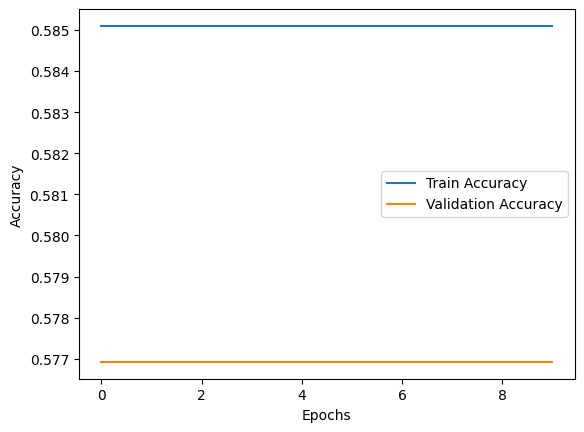

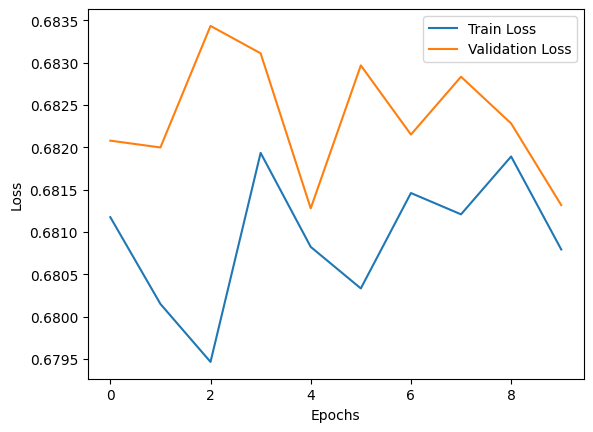

In [15]:
# Visualize Training History
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Inferencing and Prediction

In [16]:
import numpy as np

# Prediction Code
def predict_image(model, image_path, class_names):
    from tensorflow.keras.preprocessing.image import load_img, img_to_array

    # Load the image
    img = load_img(image_path, target_size=(150, 150))
    img_array = img_to_array(img) / 255.0  # Normalize the image
    img_array = np.expand_dims(img_array, axis=0)  # Expand dimensions to match model input

    # Predict the class probabilities
    prediction = model.predict(img_array)

    # Get the index of the class with the highest probability
    predicted_class_index = np.argmax(prediction[0])

    # Get the predicted class name
    predicted_class = class_names[predicted_class_index]

    return predicted_class, prediction


# Class names (Make sure this matches your dataset classes)
class_names = ['daisy', 'dandelion'] # Update with your actual class names

# Example prediction
image_path = 'dataset/test/daisy/34695914906_961f92ffcd_n_jpg.rf.de50f4cd24e39e40099bb3339d6bb101.jpg'  # Replace with your image path
predicted_class, _ = predict_image(model, image_path, class_names)
print(f"Predicted Class: {predicted_class}")



I0000 00:00:1769779807.063992   28171 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3', 8 bytes spill stores, 8 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Class: dandelion


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Class: dandelion
Prediction: [[0.45882195 0.54138786]]


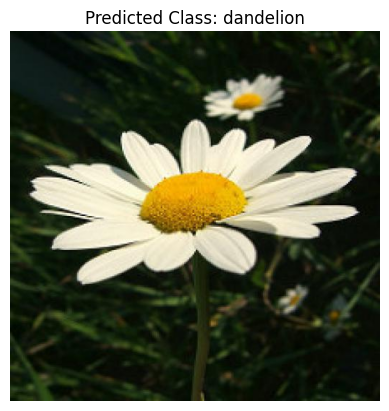

In [18]:
import cv2
import matplotlib.pyplot as plt

# Example prediction
image_path = 'dataset/valid/daisy/162362897_1d21b70621_m_jpg.rf.4bca1a07f884e7c5e21593ff199a645b.jpg'  # Replace with your image path
predicted_class, prediction = predict_image(model, image_path, class_names)
print(f"Predicted Class: {predicted_class}")
print(f"Prediction: {prediction}")
img = cv2.imread(image_path)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted Class: {predicted_class}")
plt.axis('off')
plt.show()